In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('CRH','AMZN'), 
         ('CRH','AVGO'), 
         ('CRH','GOOGL'), 
         ('TDG','AMZN'), 
         ('TDG', 'AVGO'),
         ('TDG', 'GOOGL'), 
         ('NEM','AMZN'), 
         ('NEM', 'AVGO'), 
         ('NEM','GOOGL')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.1s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, 

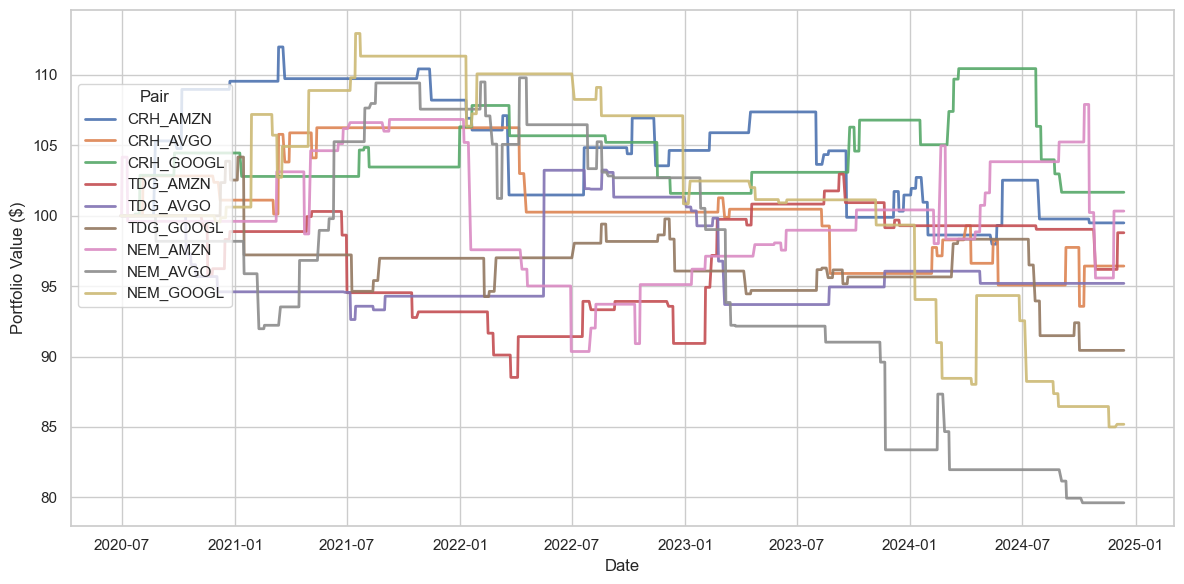

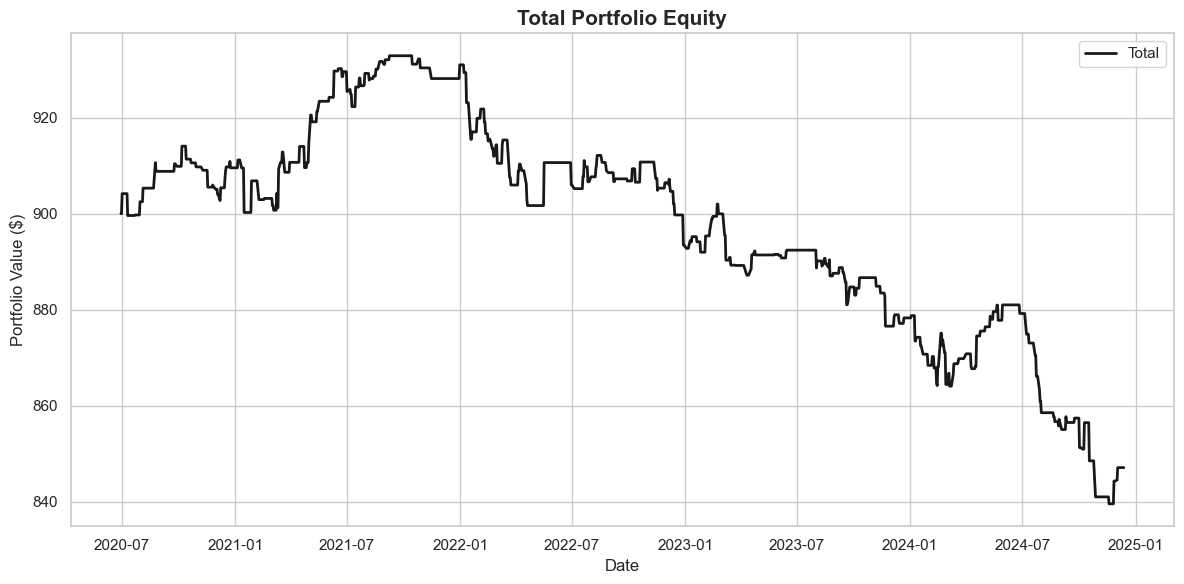

Summary
CRH_AMZN: Final Value = $99.49, Total Return = -0.51%, Trades = 35
CRH_AVGO: Final Value = $96.43, Total Return = -3.57%, Trades = 26
CRH_GOOGL: Final Value = $101.67, Total Return = 1.67%, Trades = 25
TDG_AMZN: Final Value = $98.79, Total Return = -1.21%, Trades = 34
TDG_AVGO: Final Value = $95.20, Total Return = -4.80%, Trades = 24
TDG_GOOGL: Final Value = $90.44, Total Return = -9.56%, Trades = 33
NEM_AMZN: Final Value = $100.33, Total Return = 0.33%, Trades = 38
NEM_AVGO: Final Value = $79.62, Total Return = -20.38%, Trades = 39
NEM_GOOGL: Final Value = $85.19, Total Return = -14.81%, Trades = 35

Total Portfolio Performance
Initial Portfolio Value: $900.00
Final Portfolio Value:   $847.16
Total Return:            -5.87%

Sharpe Ratios
CRH_AMZN: Sharpe Ratio = 0.02
CRH_AVGO: Sharpe Ratio = -0.11
CRH_GOOGL: Sharpe Ratio = 0.10
TDG_AMZN: Sharpe Ratio = -0.02
TDG_AVGO: Sharpe Ratio = -0.17
TDG_GOOGL: Sharpe Ratio = -0.39
NEM_AMZN: Sharpe Ratio = 0.06
NEM_AVGO: Sharpe Ratio = -

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)